# Sequential Workflows in LangGraph: BMI Calculator

## What is a sequential workflow?

A **sequential (linear) workflow** in LangGraph is a graph in which every node has exactly one outgoing edge, and control flows through the nodes in a single, fixed order: `START -> node_1 -> node_2 -> ... -> END`. There is no branching, no conditional routing, and no fan-out/fan-in. Each node receives the shared state produced by the previous node, updates it, and passes it forward.

This is in contrast to:

- **Conditional graphs**, which use `add_conditional_edges` to route to different nodes depending on the contents of the state (e.g. an `if/else` at the graph level).
- **Parallel (fan-out/fan-in) graphs**, where a single node's output edges lead to multiple nodes that execute concurrently, later converging into a joining node.

Sequential workflows are the simplest possible graph topology, and they are the right starting point for learning LangGraph's core building blocks: the **state schema**, **nodes**, **edges**, **compiling**, and **invoking**.

## What this notebook builds

This notebook implements a two-step sequential pipeline that computes a person's Body Mass Index (BMI) and labels it with a health category:

1. `calculate_bmi` — reads `weight_kg` and `height_m` from the state and writes `bmi` back into the state.
2. `label_bmi` — reads `bmi` from the state and writes a `category` string back into the state.

The graph wires these together as `START -> calculate_bmi -> label_bmi -> END`, so the state accumulates fields as it passes through the pipeline: it starts with just the two inputs and ends with all four fields populated. The remaining cells in this notebook build up to that graph piece by piece: first the state schema, then each node function, then the graph definition and edges, then compiling and invoking, and finally a visualization of the compiled graph.

## Imports

This cell imports the three pieces needed to build and type a LangGraph workflow:

- `StateGraph` — the class used to construct the graph. It is parameterized with a state schema, and exposes `add_node`, `add_edge`, and `compile` to assemble the pipeline.
- `START` and `END` — sentinel markers that represent the entry point and exit point of the graph. Every sequential graph needs an edge from `START` into its first real node, and an edge from its last real node into `END`.
- `TypedDict` (from Python's `typing` module) — used to declare the shape of the state as a plain dictionary with known keys and types, without any runtime validation overhead. LangGraph uses this schema to know which keys the state carries as it flows between nodes.

In [11]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

## Defining the state schema: `BMIState`

`BMIState` is a `TypedDict` that declares the single shared data structure every node in the graph reads from and writes to. It has four fields:

- `weight_kg` (`float`) — an input, supplied when the graph is invoked.
- `height_m` (`float`) — an input, supplied when the graph is invoked.
- `bmi` (`float`) — computed by the `calculate_bmi` node.
- `category` (`str`) — computed by the `label_bmi` node.

Note that all four fields are declared up front, even though only two of them (`weight_kg`, `height_m`) are populated at the start. This is a common pattern in LangGraph: the state schema represents the union of everything the graph will ever hold, and individual nodes progressively fill in the fields relevant to their step. Because `StateGraph` is later parameterized as `StateGraph(BMIState)`, LangGraph knows the full shape of the dictionary that will be threaded through `calculate_bmi` and `label_bmi`.

In [12]:
# define state
class BMIState(TypedDict):

    weight_kg: float
    height_m: float
    bmi: float
    category: str

## Node 1: `calculate_bmi`

This is the first node function in the graph. In LangGraph, a node is just a plain Python function that takes the current state and returns an updated state — its signature here, `calculate_bmi(state: BMIState) -> BMIState`, matches this convention exactly.

What it does:

- Reads `weight_kg` and `height_m` out of the incoming `state` dictionary.
- Applies the standard BMI formula, `bmi = weight / height**2`.
- Writes the rounded result into `state['bmi']`, mutating the same dictionary that was passed in, and returns it.

Because this function will be registered with `graph.add_node('calculate_bmi', calculate_bmi)`, LangGraph will call it with whatever state exists at that point in the graph (initially just `weight_kg` and `height_m`), and whatever it returns becomes the state passed to the next node.

In [13]:
def calculate_bmi(state: BMIState) -> BMIState:

    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)
    state['bmi'] = round(bmi, 2)
    
    return state

## Node 2: `label_bmi`

The second node function follows the same convention as the first: it accepts the current `BMIState` and returns an updated one. By the time this node runs, the state already contains the `bmi` value produced by `calculate_bmi` — this is the essence of a sequential graph, where each node builds on the output of the one before it.

What it does:

- Reads `bmi` from the state.
- Applies a chain of threshold checks (`< 18.5`, `18.5–24.9`, `25–29.9`, `>= 30`) to classify the value into `"Underweight"`, `"Normal"`, `"Overweight"`, or `"Obese"`.
- Writes the result into `state['category']` and returns the state.

After this node runs, the state dictionary is fully populated with all four fields declared in `BMIState`. This node will be registered as `graph.add_node('label_bmi', label_bmi)` and wired to run immediately after `calculate_bmi`.

In [14]:
def label_bmi(state: BMIState) -> BMIState:

    bmi = state['bmi']

    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state

## Assembling the graph: nodes, edges, and compiling

This cell performs the four steps required to turn the node functions above into an executable LangGraph workflow:

1. **Instantiate the graph**: `StateGraph(BMIState)` creates a new graph builder whose state must conform to the `BMIState` schema.
2. **Register nodes**: `graph.add_node('calculate_bmi', calculate_bmi)` and `graph.add_node('label_bmi', label_bmi)` associate a string name with each node function. This name is what edges refer to, and what shows up when the graph is visualized or traced.
3. **Wire edges**: three calls to `add_edge` define the linear path through the graph:
   - `add_edge(START, 'calculate_bmi')` — the graph's entry point.
   - `add_edge('calculate_bmi', 'label_bmi')` — the sequential hand-off between the two nodes.
   - `add_edge('label_bmi', END)` — the graph's exit point.
   Because every node here has exactly one incoming and one outgoing edge, this is precisely what makes the graph "sequential": execution has no branch points and no possible node ordering other than `calculate_bmi` then `label_bmi`.
4. **Compile**: `graph.compile()` validates the graph structure (all nodes reachable, edges consistent with the schema) and returns a `workflow` object that can actually be executed via `.invoke()`, `.stream()`, etc. The graph builder (`graph`) is a specification; `workflow` is the runnable artifact produced from it.

In [15]:
# define your graph
graph = StateGraph(BMIState)

# add nodes to your graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_bmi', label_bmi)

# add edges to your graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'label_bmi')
graph.add_edge('label_bmi', END)


# compile the graph
workflow = graph.compile()

## Running the graph: `.invoke()`

This cell executes the compiled workflow end to end:

- `intial_state` is a plain dictionary containing only the two input fields the graph needs to start: `weight_kg` and `height_m`. It does not need to include `bmi` or `category` yet, since those are produced during execution.
- `workflow.invoke(intial_state)` runs the graph synchronously from `START` to `END`: it calls `calculate_bmi` with `intial_state`, takes the returned state and passes it to `label_bmi`, and returns the final state once it reaches `END`.
- The printed `final_state` shows all four `BMIState` fields populated: the original inputs (`weight_kg`, `height_m`) plus the two fields computed along the way (`bmi`, `category`). This demonstrates the core behavior of a sequential workflow — state flows through each node in order, accumulating new fields, with no branching or skipping of steps.

In [16]:
# execute the graph
intial_state = {'weight_kg':64, 'height_m':1.67}

final_state = workflow.invoke(intial_state)
print(final_state)

{'weight_kg': 64, 'height_m': 1.67, 'bmi': 22.95, 'category': 'Normal'}


## Visualizing the compiled graph

`workflow.get_graph()` returns a graph representation of the compiled workflow (its nodes and edges), and `.draw_mermaid_png()` renders that representation as a Mermaid diagram converted to a PNG image. Wrapping the result in `IPython.display.Image` displays it inline in the notebook.

For this workflow, the rendered diagram visually confirms the linear structure described above: a single path `START -> calculate_bmi -> label_bmi -> END`, with no branches. This kind of visualization becomes especially useful once graphs grow to include conditional edges or parallel branches, where the topology is no longer obvious from reading the code alone.

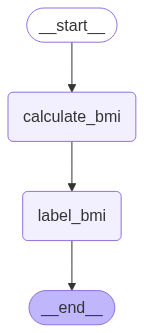

In [17]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

## Summary and generalization

This notebook walked through every step required to build the simplest possible LangGraph workflow:

- **Define a state schema** (`BMIState`, a `TypedDict`) describing every field that will ever exist in the shared state, whether supplied as input or produced by a node.
- **Write node functions** (`calculate_bmi`, `label_bmi`) that each take the state, read the fields they need, write the fields they produce, and return the updated state.
- **Build the graph** with `StateGraph(BMIState)`, register the nodes with `add_node`, and connect them in a straight line with `add_edge`, bookended by `START` and `END`.
- **Compile** the graph with `.compile()` to obtain a runnable `workflow`.
- **Invoke** the workflow with an initial state dictionary and receive back the fully populated final state.
- **Visualize** the compiled graph's topology with `get_graph().draw_mermaid_png()`.

This same skeleton generalizes directly to more complex sequential workflows: any pipeline that can be described as "step 1, then step 2, then step 3, ..." — for example a multi-stage text-processing pipeline (clean -> summarize -> translate) or a data-validation pipeline (parse -> validate -> transform) — is built by simply adding more fields to the state schema and more `add_node`/`add_edge` calls in a straight chain. The moment a workflow needs to make a decision about *which* node to run next based on the state, or needs to run multiple nodes concurrently, it moves beyond a sequential graph into conditional edges (`add_conditional_edges`) or parallel fan-out/fan-in — topics that build directly on the concepts introduced here.